## Examining the Environmental Effects of NYC's Recently-Planted Trees

In this notebook, I'll be looking at the recently planted trees from NYC Parks Street Tree Planting data (https://www.nycgovparks.org/trees/street-tree-planting/locations), as well as scraping their NYC Tree Map (https://tree-map.nycgovparks.org/) in order to examine the environmental effects of recently planted trees in NYC.

First, let's explore the data.

In [1]:
%pip install psycopg
%pip install bs4
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import psycopg
import pandas as pd
import numpy as np
import pydeck as pdk 
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import seaborn as sns
import os

The Street Tree Planting data .csv that I'm using was created through manual download through the NYC Parks Street Tree Planting Locations page, which I copy into a SQL database below. The use of a SQL database and SQL queries is for my own learning purposes, and I use Pandas to more thoroughly explore the data later in this notebook.

In [3]:
# create db
conn = psycopg.connect(
    host="localhost",
    port=5433,
    dbname="postgres",
    user="postgres",
    password=os.getenv("PG_PASSWORD")
)
conn.autocommit = True

# drop connections before dropping existing db
with conn.cursor() as cur: 
    cur.execute("""
        alter database trees_db allow_connections = off;

        SELECT pg_terminate_backend(pg_stat_activity.pid)
        FROM pg_stat_activity
        WHERE pg_stat_activity.datname = 'trees_db' 
        AND pid <> pg_backend_pid();
                """)
    cur.execute("DROP DATABASE IF EXISTS trees_db;")
    cur.execute("CREATE DATABASE trees_db;")

conn.close()

# connect to trees_db
conn = psycopg.connect(
    host="localhost",
    port=5433,
    dbname="trees_db",
    user="postgres",
    password=os.getenv("TR_PASSWORD")
)

# create table and copy
with conn:
    with conn.cursor() as cur:
        cur.execute("SELECT current_database();")
        print("Connected to:", cur.fetchone())
        cur.execute("DROP TABLE IF EXISTS trees;")
        cur.execute("""
            CREATE TABLE trees(
                    lng NUMERIC,
                    lat NUMERIC,
                    borough TEXT,
                    zipcode INTEGER,
                    building_num TEXT,
                    street_name TEXT,
                    fiscal_year INTEGER,
                    planting_space_id INTEGER,
                    community_board INTEGER,
                    planting_season DATE,
                    city_council INTEGER,
                    tree_id INTEGER,
                    work_order_id INTEGER,
                    work_order_status TEXT,
                    completed_date TIMESTAMP
            );
        """)
        
        with cur.copy("COPY trees FROM STDIN WITH CSV HEADER") as copy:
            with open("street_tree_planting_new.csv", "r") as f:
                for line in f:
                    copy.write(line)
        #print(cur.fetchall())
        cur.execute("SELECT * FROM trees LIMIT 10;")
        print(cur.fetchall())

conn.close()

Connected to: ('trees_db',)
[(Decimal('-73.99274061'), Decimal('40.67743821'), 'Brooklyn', 11231, '93', '3 STREET', 0, 2764466, 306, datetime.date(2024, 6, 30), 39, 11591666, 12843288, 'Completed', datetime.datetime(2021, 4, 20, 0, 0)), (Decimal('-73.99354637'), Decimal('40.67767986'), 'Brooklyn', 11231, '68', '3 STREET', 0, 7786870, 306, datetime.date(2024, 6, 30), 39, 11591665, 12843283, 'Completed', datetime.datetime(2021, 4, 21, 0, 0)), (Decimal('-73.99548735'), Decimal('40.68337539'), 'Brooklyn', 11231, '316', 'COURT STREET', 0, 3656119, 306, datetime.date(2024, 6, 30), 39, 11591616, 11021601, 'Completed', datetime.datetime(2021, 4, 21, 0, 0)), (Decimal('-73.99664263'), Decimal('40.68064057'), 'Brooklyn', 11231, '375', 'COURT STREET', 0, 7157816, 306, datetime.date(2024, 6, 30), 39, 11590378, 11020490, 'Completed', datetime.datetime(2021, 4, 21, 0, 0)), (Decimal('-73.99883758'), Decimal('40.67575026'), 'Brooklyn', 11231, '505', 'COURT STREET', 0, 1604126, 306, datetime.date(2024, 

Now that we're connected to our SQL database, let's explore the data with a few exploratory queries.

First, I'm interested in the distribution of recently planted trees in each borough.

In [ ]:
conn = psycopg.connect(
    host="localhost",
    port=5433,
    dbname="trees_db",
    user="postgres",
    password=os.getenv("TR_PASSWORD")
)

with conn:
    with conn.cursor() as cur:
        cur.execute("SELECT COUNT(*) FROM trees;")
        print(cur.fetchall())
        cur.execute("SELECT borough, COUNT(*) AS boro_count FROM trees GROUP BY borough ORDER BY boro_count DESC;")
        print(cur.fetchall())
conn.close()

[(9391,)]
[('Queens', 2907), ('Bronx', 2428), ('Brooklyn', 2116), ('Manhattan', 1912), ('Staten Island', 28)]


Looking at the distribution of recent trees over the boroughs, we can see that the counts seem to sum to around the number of rows in the dataset, so there are few nulls in the borough column (we'll dive deeper into nulls with Pandas later). Staten Island only has 28 trees planted recently, which is unsuprising given the much smaller area of Staten Island compared to the other boroughs.

What specific zipcodes have the most trees planted recently?

In [5]:
conn = psycopg.connect(
    host="localhost",
    port=5433,
    dbname="trees_db",
    user="postgres",
    password=os.getenv("TR_PASSWORD")
)

with conn:
    with conn.cursor() as cur:
        cur.execute("SELECT zipcode, borough, COUNT(zipcode) AS zipcode_count FROM trees GROUP BY zipcode, borough ORDER BY zipcode_count DESC LIMIT 10;")
        print(cur.fetchall())
conn.close()

[(10473, 'Bronx', 312), (10452, 'Bronx', 309), (10472, 'Bronx', 304), (10002, 'Manhattan', 246), (11416, 'Queens', 230), (11211, 'Brooklyn', 228), (10457, 'Bronx', 223), (11419, 'Queens', 219), (11206, 'Brooklyn', 210), (10453, 'Bronx', 199)]


We examine the 10 zipcodes that occur most frequently, and their corresponding boroughs. The top 3 zipcodes are all in the Bronx, and are all very close in number of occurences In the top 10, the Bronx appears five times, Queens twice, Brooklyn twice, Manhattan once. Even at the zipcode level, the Bronx still takes the spot for NYC borough with highest number of recently planted trees.

Having answered some initial questions with SQL querying, we can now dive deeper into the data with visualizations and more data exploration with Pandas.

In [6]:
# read in data
df = pd.read_csv("street_tree_planting_new.csv")
df.head()

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,CityCouncil,TreeID,WOId,WOStatus,CompletedDate
0,-73.992741,40.677438,Brooklyn,11231,93,3 STREET,0,2764466,306,06/30/2024,39,11591666,12843288,Completed,2021-04-20 00:00:00
1,-73.993546,40.677680,Brooklyn,11231,68,3 STREET,0,7786870,306,06/30/2024,39,11591665,12843283,Completed,2021-04-21 00:00:00
2,-73.995487,40.683375,Brooklyn,11231,316,COURT STREET,0,3656119,306,06/30/2024,39,11591616,11021601,Completed,2021-04-21 00:00:00
3,-73.996643,40.680641,Brooklyn,11231,375,COURT STREET,0,7157816,306,06/30/2024,39,11590378,11020490,Completed,2021-04-21 00:00:00
4,-73.998838,40.675750,Brooklyn,11231,505,COURT STREET,0,1604126,306,06/30/2024,39,11508079,12895152,Completed,2021-04-22 00:00:00


In [7]:
df.dtypes

lng                float64
lat                float64
Borough             object
ZipCode              int64
BuildingNumber      object
StreetName          object
FiscalYear           int64
PlantingSpaceID      int64
CommunityBoard       int64
PlantingSeason      object
CityCouncil          int64
TreeID               int64
WOId                 int64
WOStatus            object
CompletedDate       object
dtype: object

##### Checking for nulls and duplicates

In [8]:
print(df.isnull().sum())

lng                   0
lat                   0
Borough               0
ZipCode               0
BuildingNumber       16
StreetName            0
FiscalYear            0
PlantingSpaceID       0
CommunityBoard        0
PlantingSeason        0
CityCouncil           0
TreeID                0
WOId                  0
WOStatus              0
CompletedDate      1845
dtype: int64


In [9]:
df["WOStatus"].value_counts()

WOStatus
Completed        7546
Not Completed    1845
Name: count, dtype: int64

We're only interested in completed work orders (trees that have been planted), so we'll use compl_df from here on out.

In [10]:
# separating into completed and non-completed
compl_df = pd.DataFrame(df[df["WOStatus"] == "Completed"])
non_df = pd.DataFrame(df[df["WOStatus"] == "Not Completed"]) # just in case I examine it later

In [11]:
compl_df.tail()

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,CityCouncil,TreeID,WOId,WOStatus,CompletedDate
7541,-73.907472,40.804112,Bronx,10454,850,EAST 140 STREET,0,12112061,201,12/31/2024,8,0,24053967,Completed,2025-01-10 00:00:00
7542,-73.854419,40.815914,Bronx,10473,1966,LACOMBE AV,0,12824117,209,12/31/2024,18,0,25806219,Completed,2025-01-10 00:00:00
7543,-73.909878,40.821034,Bronx,10456,820,ST ANNS AVENUE,0,11990384,201,12/31/2024,17,0,23727473,Completed,2025-01-10 00:00:00
7544,-73.847231,40.816872,Bronx,10473,450,CASTLE HILL AVENUE,0,11409020,209,12/31/2024,18,0,22380906,Completed,2025-01-10 00:00:00
7545,-73.854511,40.815898,Bronx,10473,1966,LACOMBE AV,0,12824115,209,12/31/2024,18,0,25806216,Completed,2025-01-10 00:00:00


In [12]:
# converting date type columns into Timestamp
compl_df["CompletedDate"]= pd.to_datetime(compl_df["CompletedDate"])
compl_df["PlantingSeason"] = pd.to_datetime(compl_df["PlantingSeason"])

In [13]:
compl_df.dtypes # making sure dtype change happened

lng                       float64
lat                       float64
Borough                    object
ZipCode                     int64
BuildingNumber             object
StreetName                 object
FiscalYear                  int64
PlantingSpaceID             int64
CommunityBoard              int64
PlantingSeason     datetime64[ns]
CityCouncil                 int64
TreeID                      int64
WOId                        int64
WOStatus                   object
CompletedDate      datetime64[ns]
dtype: object

In [14]:
compl_df["TreeID"].value_counts()

TreeID
0           295
15880081      2
15885023      2
12885028      2
15763302      2
           ... 
15874136      1
15874128      1
15874127      1
15874130      1
2542533       1
Name: count, Length: 7248, dtype: int64

Looking at the TreeID column, there are 295 trees who do not have a valid tree ID (tree ID of 0), so we will not be able to find further environmental information for these trees from the NYC Tree Map. Since we're looking to analyze trees' environmental impact, we'll only include trees that have valid tree IDs.

In [15]:
compl_df = compl_df[compl_df["TreeID"] != 0]

In [16]:
compl_df[compl_df["TreeID"] == 0] # make sure all no-ID trees have been removed

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,CityCouncil,TreeID,WOId,WOStatus,CompletedDate


In [17]:
compl_df.shape

(7251, 15)

In [18]:
compl_df["TreeID"].value_counts()[:10]

TreeID
15880081    2
15885023    2
15763302    2
12885028    2
11591666    1
15893669    1
15893675    1
15893674    1
15893673    1
15886171    1
Name: count, dtype: int64

Since there are only a few duplicates, we can manually examine each duplicate TreeID record.

In [19]:
compl_df[compl_df["TreeID"]==15880081]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,CityCouncil,TreeID,WOId,WOStatus,CompletedDate
2898,-73.834895,40.658358,Queens,11414,159-052,98 STREET,0,620915,410,2024-12-31,32,15880081,24281795,Completed,2024-11-11
2899,-73.834895,40.658358,Queens,11414,159-052,98 STREET,0,620915,410,2024-12-31,32,15880081,24318769,Completed,2024-11-11


In [20]:
compl_df[compl_df["TreeID"]==15885023]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,CityCouncil,TreeID,WOId,WOStatus,CompletedDate
4431,-74.000438,40.744485,Manhattan,10011,319,WEST 21 STREET,0,1595261,104,2024-12-31,3,15885023,7260535,Completed,2024-11-29
4432,-74.000438,40.744485,Manhattan,10011,319,WEST 21 STREET,0,1595261,104,2024-12-31,3,15885023,16644293,Completed,2024-11-29


In [21]:
compl_df[compl_df["TreeID"]==15763302]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,CityCouncil,TreeID,WOId,WOStatus,CompletedDate
1974,-73.893221,40.851106,Bronx,10457,2120,QUARRY ROAD,0,2467794,206,2024-12-31,15,15763302,24467264,Completed,2024-10-24
6863,-73.893221,40.851106,Bronx,10457,2120,QUARRY ROAD,0,2467794,206,2024-12-31,15,15763302,23608334,Completed,2024-12-19


In [22]:
compl_df[compl_df["TreeID"]==12885028]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,CityCouncil,TreeID,WOId,WOStatus,CompletedDate
360,-73.841722,40.691799,Queens,11418,91-017,104 STREET,0,9404955,409,2024-12-31,32,12885028,17055437,Completed,2022-05-17
361,-73.841722,40.691799,Queens,11418,91-017,104 STREET,0,9404955,409,2024-12-31,32,12885028,17054633,Completed,2022-05-17


Looking at the duplicates, we can see that the only difference between duplicate records are their Work Order ID (WOId), but we can ignore this as we only care about whether this particular tree was planted. Thus, we arbitratily remove duplicates (in this case, removing the latter duplicate record).

In [23]:
compl_df.drop_duplicates(subset=["TreeID"], keep="first", inplace=True)

In [24]:
compl_df["TreeID"].value_counts()[:5]

TreeID
11591666    1
15893739    1
15893675    1
15893674    1
15893673    1
Name: count, dtype: int64

Now that we've cleaned up the duplicates, we can go ahead and make an initial visualization of recently-planted-tree distribution, overlaid on NYC's geography.

##### Visualizing recently-planted trees using Pydeck

In [441]:
# create visualization of existing completed records first

# define Layer
layer = pdk.Layer(
    "HexagonLayer",
    compl_df[["lng", "lat"]],
    radius = 150,
    get_position=["lng", "lat"],
    auto_highlight=True,
    elevation_scale=6,
    pickable=True,
    elevation_range=[0, 3000],
    extruded=True,
    coverage=1,
)

# set viewport location
view_state = pdk.ViewState(
    longitude=-73.9,
    latitude=40.72,
    zoom=9.5,
    min_zoom=8,
    max_zoom=15,
    pitch=5,
    bearing=-27.36,
)

# render
r = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    tooltip={
        'html': '<text>Number of newly planted trees:</text> {elevationValue}',
        'style': {
            'color': 'white'
        }
    }
)
r.to_html("hexagon_layer.html")

We can see that the highest density of recently-planted trees (red bars) are scattered throughout Brooklyn and Queens, but the borough with the widest-ranging concentration of trees is Manhattan, most of whose area is dotted with points.

Now that we've finished an initial exploration of the data, we can scrape data from the NYC Tree Map to get the environmental impact information of each tree.

#### Scraping NYC Tree Map for environmental data

There doesn't seem to be rules against scraping on the nyc.gov robots.txt, so I'm going ahead with scraping the NYC Tree Map.

In [26]:
import requests
from bs4 import BeautifulSoup

For each tree: we want to know if 
1. if it's on the map: the ecological details
2. the species of that tree

We only want trees that have ecological data (trees that are on the NYC Tree Map), so we'll separate those out first.

In [ ]:
# check for status code 200
url = "https://tree-map.nycgovparks.org/tree-map/tree/2560007"
res = requests.get(url)
print(res.status_code)

200


In [28]:
dom = BeautifulSoup(res.text)

In [29]:
dom.text

'Ash near 1795 Gleason AvenueNYC ParksNew York City Tree MapExplore and Care For NYC’s Urban ForestMenuText SizeLanguageMapMy TreesLearnGroupsShareTweetFavoriteReport ProblemView MapClosest Address Tree ID Number Trunk Diameter Suggest an EditNominate as Great TreeLatest Inspection ResultsNov 26, 2024A Forester has inspected this tree.Nov 26, 2024Work Order #25612118 created. A Parks contractor will prune the tree.Learn more about these\xa0resultsTree Care ActivitiesThere are no activities reported for this tree. Click the “Record Tree Care” button below to log activity.Record Tree CareEcological BenefitsStormwater intercepted each year3,786 gallonsValue: $37.48Energy conserved each year2,044 kWhValue: $258Air pollutants removed each year5 poundsValue: $24.9Total Value of Annual BenefitsValue: $334.42Benefits are calculated using formulas from the U.S. Forest Service.Learn more about the benefits of trees to\xa0NYCTree Species/SizesMap Key Tree marker color indicates species. Marker si

In [ ]:
# Just in case someone is using this code: the cell below takes ~35 minutes to run!

In [31]:
# filter out the ID urls that have eco benefits

water = []
energy = []
air = []
total = []
valid_ids = []
species_in_order = []
diameters = []

for id in compl_df["TreeID"]:
    url = f"https://tree-map.nycgovparks.org/tree-map/tree/{id}"
    res = requests.get(url)
    #print(res.status_code)
    if res.status_code == 200:
        valid_ids.append(id)
        dom = BeautifulSoup(res.text)
        # set up lists
        eco_ben_span = dom.select(".EcologicalBenefits_amount__piGe9")
        if eco_ben_span == []:
            water.append(None)
            energy.append(None)
            air.append(None)
            total.append(None)
            species_in_order.append(None)
            diameters.append(None)
            continue
        else: # get environmental info
            for eco_box in eco_ben_span:
                if eco_ben_span.index(eco_box) == 0:
                    water.append(int(eco_box.contents[0].replace(",", "")))
                if eco_ben_span.index(eco_box) == 2:
                    energy.append(int(eco_box.contents[0].replace(",", "")))
                if eco_ben_span.index(eco_box) == 4:
                    air.append(int(eco_box.contents[0].replace(",", "")))
                if eco_ben_span.index(eco_box) == len(eco_ben_span) - 1:
                     total.append(float(eco_box.contents[-1].replace(",", "")))
            # get diameter and species
            # diameter
            td_box = dom.select("#__NEXT_DATA__")
            td_match = re.search(r"stumpDiameter\":(\d+)", str(td_box)).group(1).strip()
            if td_match == None:
                continue
            else:
                diameter = td_match
                diameters.append(int(diameter))
            # species
            sp_match = re.search(r"\"*([A-Za-z ']+) (near|unknown)", dom.text[:80]) 
            if sp_match == None:
                cn_box = dom.select("#__NEXT_DATA__")
                cn_match = re.search(r"commonName\":\"([A-Za-z ]+)\"", str(cn_box)).group(1).strip()
                if cn_match == None:
                    continue
                else:
                    species = cn_match
                    species_in_order.append(species)
                    print(f"common name: {species}")
            else:
                species = sp_match.group(1).strip()
                species_in_order.append(species)


common name: Japanese flowering cherry


Here, I make sure that the lengths of each list align with the expected outcome.

In [32]:
len(water) == len(species_in_order) == len(valid_ids) == len(diameters)

True

This new environmental and species data is packaged into a DataFrame, and some initial exploration is performed.

In [33]:
eco_df = pd.DataFrame({"TreeID": valid_ids, "species":species_in_order, "diameter":diameters, "water_saved": water, "energy_saved": energy, "air_saved": air, "total_saved": total})
eco_df.head()

,TreeID,species,diameter,water_saved,energy_saved,air_saved,total_saved
0,11591666,Amur maackia,3.0,383.0,227.0,0.0,34.49
1,11591665,Goldenrain tree,3.0,195.0,239.0,0.0,34.42
2,11591616,None,NaN,NaN,NaN,NaN,NaN
3,11590378,Hardy rubber tree,3.0,346.0,606.0,1.0,84.30
4,11508079,Dawn redwood,3.0,346.0,606.0,1.0,84.30


To clarify, the units of the columns are:
- diameter: Tree's trunk diameter in inches
- water_saved: Gallons of stormwater intercepted per year
- energy_saved: Kilowatt-hours of energy conserved each year
- air_saved: Pounds of air pollutants removed each year
- total_saved: Total value of annual benefits, in dollars

Let's look do some initial exploration of this ecological data!

In [34]:
eco_df.shape

(7241, 7)

In [35]:
eco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7241 entries, 0 to 7240
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TreeID        7241 non-null   int64  
 1   species       288 non-null    object 
 2   diameter      288 non-null    float64
 3   water_saved   288 non-null    float64
 4   energy_saved  288 non-null    float64
 5   air_saved     288 non-null    float64
 6   total_saved   288 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 396.1+ KB


Since we determined that trees without valid tree IDs on the NYC Tree Map should have null values in this dataset, there seem to be 288 trees that are recent tree plantings (valid tree ID) and also on the NYC Tree Map. 

In [36]:
eco_df = eco_df[eco_df['water_saved'].notnull()] # remove NaNs

In [37]:
eco_df.info() # confirm that NaNs were removed

<class 'pandas.core.frame.DataFrame'>
Index: 288 entries, 0 to 7240
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TreeID        288 non-null    int64  
 1   species       288 non-null    object 
 2   diameter      288 non-null    float64
 3   water_saved   288 non-null    float64
 4   energy_saved  288 non-null    float64
 5   air_saved     288 non-null    float64
 6   total_saved   288 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 18.0+ KB


In [38]:
print(eco_df['species'].value_counts().keys())

Index(['Pin oak', 'Japanese flowering cherry', 'Japanese zelkova',
       'Dawn redwood', 'Hardy rubber tree', 'Littleleaf linden',
       'Kentucky coffeetree', 'Callery pear', 'Common hackberry', 'White oak',
       'Hedge maple', 'Norway maple', 'Thornless honeylocust', 'Red maple',
       'Amur maackia', 'Goldenrain tree', 'Paperbark maple', 'Bur oak',
       'Shingle oak', 'Sweetgum', 'Green ash', 'River birch',
       'Northern red oak', 'Japanese pagoda tree', 'London planetree',
       'Eastern redbud', 'Swamp white oak', 'Scarlet oak', 'American hornbeam',
       'Ginkgo', 'Hawthorn', 'Unknown', 'Kentucky yellowwood',
       'American basswood', 'Serviceberry', 'Japanese tree lilac',
       'Sugar maple', 'Apple', 'Sycamore maple', 'Chinkapin oak',
       'Carolina silverbell', 'American elm', 'Northern pin oak',
       'Hophornbeam', 'Sargent's apple', 'European hornbeam',
       'Eastern cottonwood', 'Black cherry', 'Willow oak', 'American beech',
       'Maple', 'Chinese fr

In [39]:
eco_df[eco_df["species"] == "Unknown"]

,TreeID,species,diameter,water_saved,energy_saved,air_saved,total_saved
173,3272151,Unknown,10.0,2177.0,1432.0,3.0,229.98
831,12812658,Unknown,4.0,32.0,23.0,0.0,3.39


Looking at the species column, we can see a null value -- "Unknown". Examining the information from the Tree Map itself, these two trees' species is listed as 'Unknown'. However, we have ecological information for these trees, so I think it would be fun to try to "estimate" their species, based on comparisons with other species' metrics. These records will not be included in calculations for the other species, but will be included in overall calculations (for example, a visualization of stormwater value distribution).

Let's continue the eco_df exploration!

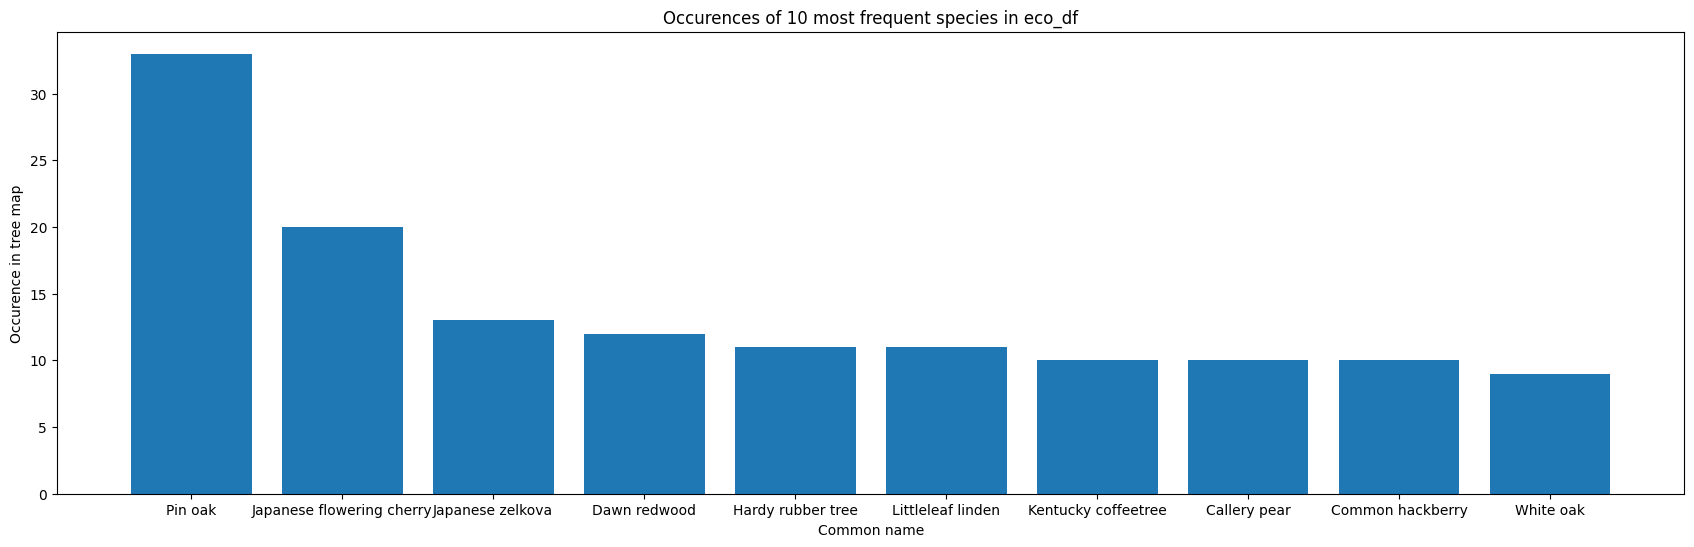

In [40]:
# plot the 10 most frequent species of recent NYC tree plantings
plt.figure(figsize=(21, 6))
plt.bar(eco_df["species"].value_counts()[:10].keys(), eco_df["species"].value_counts()[:10])
plt.xlabel("Common name")
plt.ylabel("Occurence in tree map")
plt.title("Occurences of 10 most frequent species in eco_df")
plt.show()

#### Join the ecological dataset to our original dataset

In [42]:
# join
tree_df = pd.merge(compl_df, eco_df, on="TreeID")
tree_df.head()

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,TreeID,WOId,WOStatus,CompletedDate,species,diameter,water_saved,energy_saved,air_saved,total_saved
0,-73.992741,40.677438,Brooklyn,11231,93,3 STREET,0,2764466,306,2024-06-30,...,11591666,12843288,Completed,2021-04-20,Amur maackia,3.0,383.0,227.0,0.0,34.49
1,-73.993546,40.677680,Brooklyn,11231,68,3 STREET,0,7786870,306,2024-06-30,...,11591665,12843283,Completed,2021-04-21,Goldenrain tree,3.0,195.0,239.0,0.0,34.42
2,-73.996643,40.680641,Brooklyn,11231,375,COURT STREET,0,7157816,306,2024-06-30,...,11590378,11020490,Completed,2021-04-21,Hardy rubber tree,3.0,346.0,606.0,1.0,84.30
3,-73.998838,40.675750,Brooklyn,11231,505,COURT STREET,0,1604126,306,2024-06-30,...,11508079,12895152,Completed,2021-04-22,Dawn redwood,3.0,346.0,606.0,1.0,84.30
4,-74.016429,40.676310,Brooklyn,11231,252,CONOVER STREET,0,279250,306,2024-06-30,...,5663128,637906,Completed,2021-04-27,Dawn redwood,3.0,346.0,606.0,1.0,84.30


In [43]:
tree_df.shape

(288, 21)

#### Visualize the trees we have ecological information for

In [437]:
# create visualization of 288 have-eco-knowledge trees

# define Layer
layer = pdk.Layer(
    "HexagonLayer",
    tree_df[["lng", "lat"]],
    radius = 70,
    get_position=["lng", "lat"],
    auto_highlight=True,
    elevation_scale=6,
    pickable=True,
    elevation_range=[0, 3000],
    extruded=True,
    coverage=1,
)


# set the viewport location
view_state = pdk.ViewState(
    longitude=-73.9,
    latitude=40.72,
    zoom=9.5,
    min_zoom=8,
    max_zoom=15,
    pitch=10,
    bearing=-27.36,
)

# render
r = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    tooltip={
        'html': '<text>Number of newly planted trees:</text> {elevationValue}',
        'style': {
            'color': 'white'
        }
    }
)
r.to_html("hexagon_layer.html")

The trees that we have ecological information for (through NYC Tree Map) are concentrated in the Bronx, and in parts of Manhattan and Queens. However, the highest concentration is in the middle of Queens, similar to the areas with highest concentration in our first, wider dataset of newly-planted trees.

#### Dive into ecological metrics

We can see below that ecological benefits of a tree often increase with the diameter of the tree (how large the tree is), specifically within trees of the same species.

In [45]:
eco_df[eco_df["species"]=="Green ash"]

,TreeID,species,diameter,water_saved,energy_saved,air_saved,total_saved
418,4132673,Green ash,12.0,1804.0,1308.0,3.0,200.25
1644,2504024,Green ash,14.0,1804.0,1308.0,3.0,200.25
3885,3845547,Green ash,25.0,4877.0,2303.0,6.0,392.99
6891,584315,Green ash,12.0,1804.0,1308.0,3.0,200.25
6994,584314,Green ash,12.0,1804.0,1308.0,3.0,200.25


What's the distribution of the intercepted stormwater values for these recently planted trees?

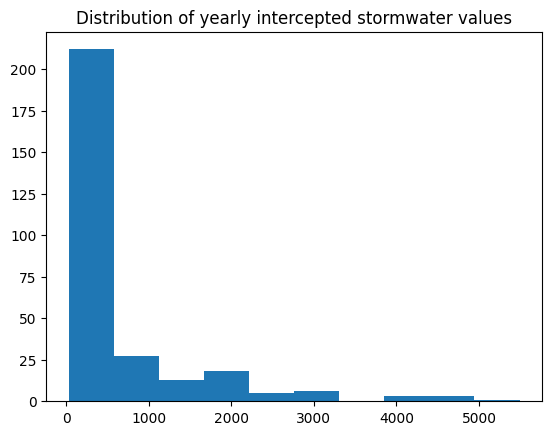

In [46]:
plt.hist(tree_df["water_saved"])
plt.title("Distribution of yearly intercepted stormwater values")
plt.show()

In [47]:
tree_df["water_saved"].groupby([tree_df["species"], tree_df["diameter"]]).max()

species            diameter
American basswood  3.0          605.0
                   17.0        2483.0
American beech     2.0          346.0
American elm       10.0         877.0
American hornbeam  3.0          383.0
                                ...  
Unknown            4.0           32.0
                   10.0        2177.0
White oak          2.0          351.0
                   3.0          351.0
Willow oak         28.0        4026.0
Name: water_saved, Length: 147, dtype: float64

In [48]:
sp_w_gb = tree_df.groupby(["species"])["water_saved"].median().nlargest(5)
sp_w_gb

species
Willow oak          4026.0
Maple               3183.0
Silver maple        3183.0
Eastern redcedar    2430.0
Sycamore maple      2293.0
Name: water_saved, dtype: float64

##### Handling nulls

In [49]:
# check for nulls in diameter values
0.0 in tree_df["diameter"].value_counts().keys()

True

In [50]:
tree_df[tree_df["diameter"] == 0.0]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,TreeID,WOId,WOStatus,CompletedDate,species,diameter,water_saved,energy_saved,air_saved,total_saved
43,-73.712984,40.735428,Queens,11001,254-04,84 ROAD,0,177638,413,2024-06-30,...,142438,8573730,Completed,2021-12-07,Norway maple,0.0,32.0,23.0,0.0,3.39
116,-73.906730,40.699999,Queens,11385,55-50,MYRTLE AVE,0,4993636,405,2024-06-30,...,4621987,10254452,Completed,2022-05-23,Thornless honeylocust,0.0,29.0,47.0,0.0,6.60
210,-73.918907,40.809867,Bronx,10454,494,EAST 141 STREET,0,2786115,201,2024-12-31,...,2556047,20621177,Completed,2024-12-09,Japanese flowering cherry,0.0,195.0,239.0,0.0,34.42


A 0-inch diameter is improbable for these trees, and looking at their Tree Map entries, these trees have a trunk diameter of "Unknown". Let's see if there's enough information to impute these values using similar trees.

In [51]:
tree_df[tree_df["species"] == "Norway maple"]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,TreeID,WOId,WOStatus,CompletedDate,species,diameter,water_saved,energy_saved,air_saved,total_saved
43,-73.712984,40.735428,Queens,11001,254-04,84 ROAD,0,177638,413,2024-06-30,...,142438,8573730,Completed,2021-12-07,Norway maple,0.0,32.0,23.0,0.0,3.39
160,-73.800591,40.719179,Queens,11432,82-21,166 STREET,0,4409753,408,2024-12-31,...,4128485,21560207,Completed,2023-12-20,Norway maple,22.0,3183.0,1744.0,4.0,293.40
163,-73.789063,40.725749,Queens,11432,176-67,80 ROAD,0,4304172,408,2024-12-31,...,4004956,23232525,Completed,2024-06-05,Norway maple,18.0,2177.0,1432.0,3.0,229.98
165,-73.777538,40.717871,Queens,11432,186-15,HENLEY ROAD,0,4425835,408,2024-12-31,...,4136120,23092288,Completed,2024-06-07,Norway maple,14.0,1310.0,1067.0,2.0,164.69
229,-73.902171,40.864338,Bronx,10468,2499,GRAND AVENUE,0,2450962,207,2024-12-31,...,2249300,21580132,Completed,2024-12-18,Norway maple,11.0,1310.0,1067.0,2.0,164.69
256,-73.890143,40.851670,Bronx,10457,2178,ARTHUR AVENUE,0,3165268,206,2024-12-31,...,2916040,23805759,Completed,2024-12-20,Norway maple,7.0,605.0,591.0,1.0,87.86
270,-73.899953,40.869571,Bronx,10468,2730,UNIVERSITY AVENUE,0,2450130,208,2024-12-31,...,2248468,24749440,Completed,2024-12-30,Norway maple,11.0,1310.0,1067.0,2.0,164.69
271,-73.900046,40.869451,Bronx,10468,2724,UNIVERSITY AVENUE,0,2450131,208,2024-12-31,...,2248469,24749431,Completed,2024-12-30,Norway maple,12.0,1310.0,1067.0,2.0,164.69


Looking at the other Norway maples, our tree of interest has much lower values across all metrics (water, energy, air, and total saved). We can assume that this tree is simply too small and young to be properly measured, and its diameter is likely under an inch.

In [52]:
tree_df[tree_df["species"] == "Thornless honeylocust"]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,TreeID,WOId,WOStatus,CompletedDate,species,diameter,water_saved,energy_saved,air_saved,total_saved
71,-73.936220,40.744966,Queens,11101,30-30,THOMSON AVENUE,0,3657026,402,2024-06-30,...,3367734,8870066,Completed,2022-03-02,Thornless honeylocust,3.0,372.0,336.0,1.0,49.22
72,-73.926379,40.760903,Queens,11106,32-44,31 STREET,0,3636909,401,2024-06-30,...,3357269,9466973,Completed,2022-03-07,Thornless honeylocust,11.0,2071.0,1538.0,3.0,235.05
116,-73.906730,40.699999,Queens,11385,55-50,MYRTLE AVE,0,4993636,405,2024-06-30,...,4621987,10254452,Completed,2022-05-23,Thornless honeylocust,0.0,29.0,47.0,0.0,6.60
126,-73.898575,40.699452,Queens,11385,73-08,FOREST AVENUE,0,3638106,405,2024-06-30,...,3342840,10254439,Completed,2022-05-24,Thornless honeylocust,5.0,1022.0,915.0,2.0,135.22
191,-73.867315,40.828073,Bronx,10472,1150,COMMONWEALTH AVENUE,0,2472234,209,2024-12-31,...,2270572,24416091,Completed,2024-11-22,Thornless honeylocust,15.0,3276.0,1960.0,4.0,310.95
237,-73.892198,40.847821,Bronx,10457,600,EAST 179 STREET,0,3634944,206,2024-12-31,...,3345526,24164875,Completed,2024-12-19,Thornless honeylocust,14.0,2071.0,1538.0,3.0,235.05
266,-73.888186,40.847899,Bronx,0,713,EAST 180 STREET,0,4018993,206,2024-12-31,...,3746989,24089439,Completed,2024-12-30,Thornless honeylocust,6.0,1022.0,915.0,2.0,135.22
277,-73.882355,40.851346,Bronx,10460,2321,SOUTHERN BOULEVARD,0,3163733,206,2024-12-31,...,2914505,24201473,Completed,2024-12-31,Thornless honeylocust,4.0,372.0,336.0,1.0,49.22


The same seems to follow for this thornless honeylocust. What about the last null-diameter tree, the Japanese flowering cherry?

In [53]:
tree_df[tree_df["species"] == "Japanese flowering cherry"][9:11]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,TreeID,WOId,WOStatus,CompletedDate,species,diameter,water_saved,energy_saved,air_saved,total_saved
210,-73.918907,40.809867,Bronx,10454,494,EAST 141 STREET,0,2786115,201,2024-12-31,...,2556047,20621177,Completed,2024-12-09,Japanese flowering cherry,0.0,195.0,239.0,0.0,34.42
211,-73.918394,40.809651,Bronx,10454,494,EAST 141 STREET,0,2786120,201,2024-12-31,...,2556052,20621178,Completed,2024-12-09,Japanese flowering cherry,4.0,195.0,239.0,0.0,34.42


This last tree seems to have the same exact metrics as another tree of the same species, so we can go ahead and impute its diameter with 4.0, the same as this other Japanese flowering cherry.

In [54]:
tree_df.iloc[210, 16] = 4.0

In [55]:
tree_df.iloc[[210]]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,TreeID,WOId,WOStatus,CompletedDate,species,diameter,water_saved,energy_saved,air_saved,total_saved
210,-73.918907,40.809867,Bronx,10454,494,EAST 141 STREET,0,2786115,201,2024-12-31,...,2556047,20621177,Completed,2024-12-09,Japanese flowering cherry,4.0,195.0,239.0,0.0,34.42


As for the other two trees whose diameter is likely very small, we will remove those trees, since we can't calculate a probable value, and so can't be sure about their true value.

In [56]:
tree_df = tree_df.drop([43, 116])

In [57]:
tree_df.iloc[[43, 115]]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,TreeID,WOId,WOStatus,CompletedDate,species,diameter,water_saved,energy_saved,air_saved,total_saved
44,-73.897193,40.658008,Brooklyn,11207,684,HINSDALE ST,0,2654511,305,2024-06-30,...,12183702,14557323,Completed,2021-12-07,Ginkgo,3.0,135.0,151.0,0.0,21.87
117,-73.910144,40.701488,Queens,11385,1678,GATES AVENUE,0,4158059,405,2024-06-30,...,5127735,10254422,Completed,2022-05-23,Pin oak,3.0,351.0,262.0,0.0,38.75


Now that we've imputed or removed diameter values, I'm curious about which trees have the highest ratios of resource_saved to their diameter.

In [ ]:
# get species' water_saved / diameter ratio, and repeat across energy and air, and then total 
tree_df["water_diam_ratio"] = tree_df["water_saved"] / tree_df["diameter"]
tree_df["nrg_diam_ratio"] = tree_df["energy_saved"] / tree_df["diameter"]
tree_df["air_diam_ratio"] = tree_df["air_saved"] / tree_df["diameter"]
tree_df["total_diam_ratio"] = tree_df["total_saved"] / tree_df["diameter"]


In [ ]:
# get top 3 in each category
w_d_top3 = tree_df.sort_values(by="water_diam_ratio", ascending=False)[:3]
e_d_top3 = tree_df.sort_values(by="nrg_diam_ratio", ascending=False)[:3]
a_d_top3 = tree_df.sort_values(by="air_diam_ratio", ascending=False)[:3]
t_d_top3 = tree_df.sort_values(by="total_diam_ratio", ascending=False)[:3]



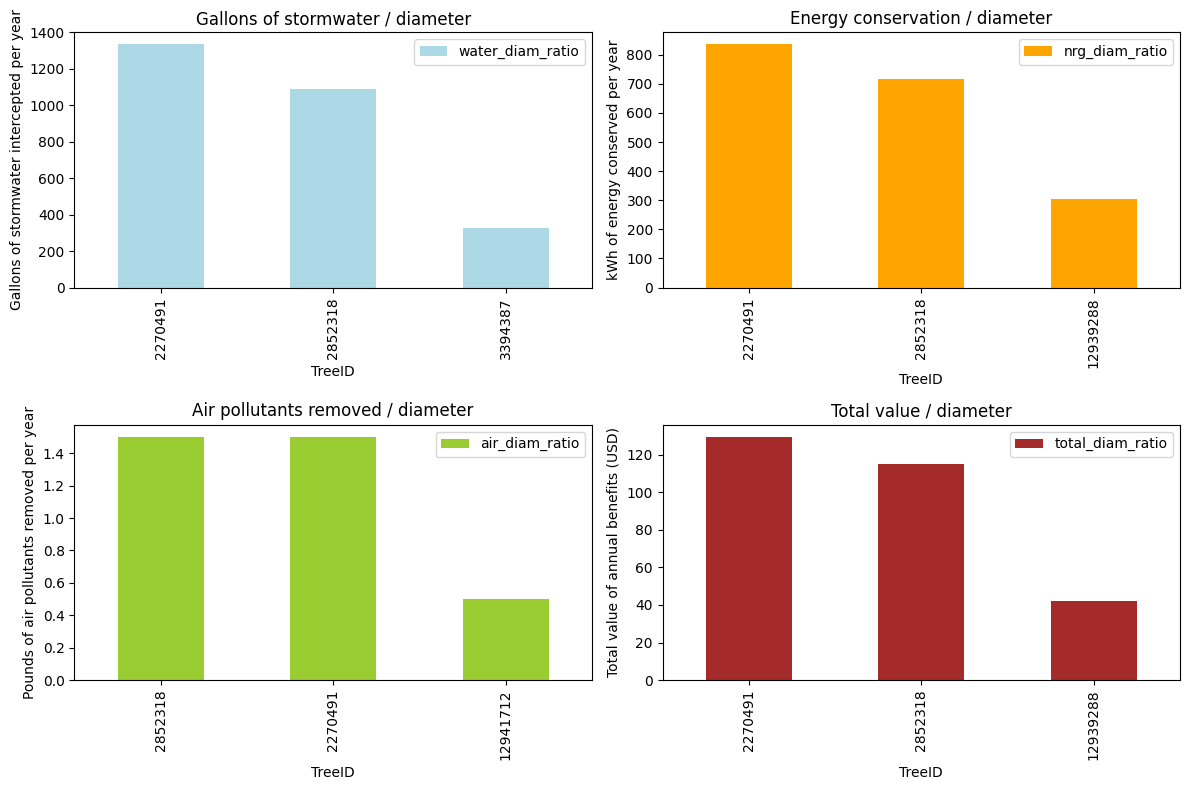

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

w_d_top3.plot(
    kind="bar", 
    x="TreeID", 
    y="water_diam_ratio", 
    ax=axes[0,0], 
    title="Gallons of stormwater / diameter", 
    color="lightblue", 
    ylabel="Gallons of stormwater intercepted per year")

e_d_top3.plot(
    kind="bar", 
    x="TreeID", 
    y="nrg_diam_ratio", 
    ax=axes[0,1], 
    title="Energy conservation / diameter", 
    color="orange", 
    ylabel="kWh of energy conserved per year")

a_d_top3.plot(
    kind="bar", 
    x="TreeID", 
    y="air_diam_ratio", 
    ax=axes[1,0], 
    title="Air pollutants removed / diameter", 
    color="yellowgreen", 
    ylabel="Pounds of air pollutants removed per year")

t_d_top3.plot(
    kind="bar", 
    x="TreeID", 
    y="total_diam_ratio", 
    ax=axes[1,1], 
    title="Total value / diameter", 
    color="brown", 
    ylabel="Total value of annual benefits (USD)")

plt.tight_layout()
plt.show()


Looking at the top 3 trees by each metric, the top 2 spots are taken by a river birch and a red maple, while the other third-place trees are various species (Japanese zelkova, Kentucky coffetree, and another river birch). 2270491 (a red maple) has the largest resource-to-diameter ratio over all metrics, though it does tie with the river birch for air pollutants removed.


Let's look at all trees included in the top 3 metrics rankings.

In [61]:
# top 2 trees
tree_df[(tree_df["TreeID"] == 2270491) | (tree_df["TreeID"] == 2852318)]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,species,diameter,water_saved,energy_saved,air_saved,total_saved,water_diam_ratio,nrg_diam_ratio,air_diam_ratio,total_diam_ratio
137,-73.903578,40.703707,Queens,11385,787,WOODWARD AVE,0,3087130,405,2024-06-30,...,River birch,2.0,2177.0,1432.0,3.0,229.98,1088.5,716.0,1.5,114.990
200,-73.869469,40.828982,Bronx,10472,1149,NOBLE AVENUE,0,2472153,209,2024-12-31,...,Red maple,2.0,2668.0,1670.0,3.0,258.91,1334.0,835.0,1.5,129.455


In [62]:
# other trees than the re-occuring top 2
tree_df[(tree_df["TreeID"] == 3394387) | (tree_df["TreeID"] == 12939288)  | (tree_df["TreeID"] == 12941712)]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,species,diameter,water_saved,energy_saved,air_saved,total_saved,water_diam_ratio,nrg_diam_ratio,air_diam_ratio,total_diam_ratio
60,-73.991482,40.768699,Manhattan,10019,538,WEST 55 STREET,0,2340167,104,2024-06-30,...,Japanese zelkova,2.0,346.0,606.0,1.0,84.30,173.0,303.00,0.5,42.1500
91,-73.840083,40.776574,Queens,11356,128-17,25 AVENUE,0,8905855,407,2024-06-30,...,Kentucky coffeetree,2.0,346.0,606.0,1.0,84.30,173.0,303.00,0.5,42.1500
138,-73.904374,40.702631,Queens,11385,1855,PUTNAM AVE,0,3683290,405,2024-06-30,...,River birch,4.0,1310.0,1067.0,2.0,164.69,327.5,266.75,0.5,41.1725


These "top 2" trees' resource metrics seem unusually large, compared to the other trees included in the top 3 rankings.

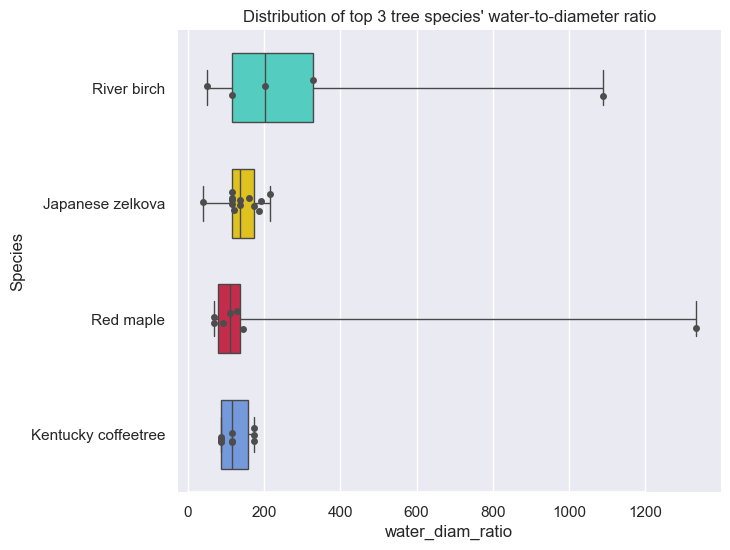

In [63]:
spec_water_df = pd.DataFrame({"species":[], "water_diam_ratio":[]})

for species in ["River birch", "Japanese zelkova", "Red maple", "Kentucky coffeetree"]:
    spec_water_df = pd.concat([spec_water_df, tree_df[tree_df["species"] == species][['species', 'water_diam_ratio']]])


sns.set_theme(style="darkgrid")
sp_color = {"River birch": "turquoise", "Japanese zelkova": "gold", "Red maple": "crimson", "Kentucky coffeetree": "cornflowerblue"}
f, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(
spec_water_df, x="water_diam_ratio", y="species", hue="species", palette=sp_color,
whis=[0, 100], width=.6
)

sns.stripplot(spec_water_df, x="water_diam_ratio", y="species", size=5, color=".3")

ax.xaxis.grid(True)
ax.set(ylabel="Species", title="Distribution of top 3 tree species' water-to-diameter ratio")
sns.despine(trim=True, left=True)
plt.show()


#### Examining and handling outliers

Looking at the distribution of water saved for each species in the top 3, we can see two clear outlier points for the river birch and red maple species' water-to-diameter ratio. Let's take a look at these points first!

In [64]:
spec_water_df.sort_values(by="water_diam_ratio", ascending=False)[:2] # get index

,species,water_diam_ratio
200,Red maple,1334.0
137,River birch,1088.5


In [65]:
tree_df.iloc[198:199] # red maple

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,species,diameter,water_saved,energy_saved,air_saved,total_saved,water_diam_ratio,nrg_diam_ratio,air_diam_ratio,total_diam_ratio
200,-73.869469,40.828982,Bronx,10472,1149,NOBLE AVENUE,0,2472153,209,2024-12-31,...,Red maple,2.0,2668.0,1670.0,3.0,258.91,1334.0,835.0,1.5,129.455


In [66]:
tree_df.iloc[135:136] # river birch

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,species,diameter,water_saved,energy_saved,air_saved,total_saved,water_diam_ratio,nrg_diam_ratio,air_diam_ratio,total_diam_ratio
137,-73.903578,40.703707,Queens,11385,787,WOODWARD AVE,0,3087130,405,2024-06-30,...,River birch,2.0,2177.0,1432.0,3.0,229.98,1088.5,716.0,1.5,114.99


Both of their diameters are 2 inches, which seems normal, but their metrics for resources saved are unusually high for a 2-inch tree of their species, across the board.

In [67]:
tree_df[(tree_df["species"] == "River birch")]["diameter"]

119    4.0
136    3.0
137    2.0
138    4.0
260    3.0
Name: diameter, dtype: float64

In [68]:
tree_df[(tree_df["species"] == "Red maple")]["diameter"]

49      3.0
140    15.0
172    20.0
176    17.0
181     9.0
198     3.0
200     2.0
Name: diameter, dtype: float64

Now that we have context from other same-species trees, it's obvious that these trees have the incorrect metrics for their size. These "top 2" trees have the smallest diameter out of their species' subset of the dataset, but still manage to get much higher resources saved, which seems unlikely. Thus, we remove both of these trees from the dataset.

In [69]:
tree_df = tree_df.drop([137, 200])

#### Back to examining metrics, now by species

Mean over all metrics: trying to see top species not just top trees

In [70]:
# mean over all metrics, sorted by water_diam_ratio, top 5 species
w_sp_top_5 = tree_df.groupby("species")[["water_diam_ratio"]].mean().sort_values(by="water_diam_ratio", ascending=False).head()
e_sp_top_5 = tree_df.groupby("species")[["nrg_diam_ratio"]].mean().sort_values(by="nrg_diam_ratio", ascending=False).head()
a_sp_top_5 = tree_df.groupby("species")[["air_diam_ratio"]].mean().sort_values(by="air_diam_ratio", ascending=False).head()
t_sp_top_5 = tree_df.groupby("species")[["total_diam_ratio"]].mean().sort_values(by="total_diam_ratio", ascending=False).head()

In [71]:
w_sp_top_5.index

Index(['Sycamore maple', 'Sawtooth oak', 'American basswood', 'River birch',
       'American beech'],
      dtype='object', name='species')

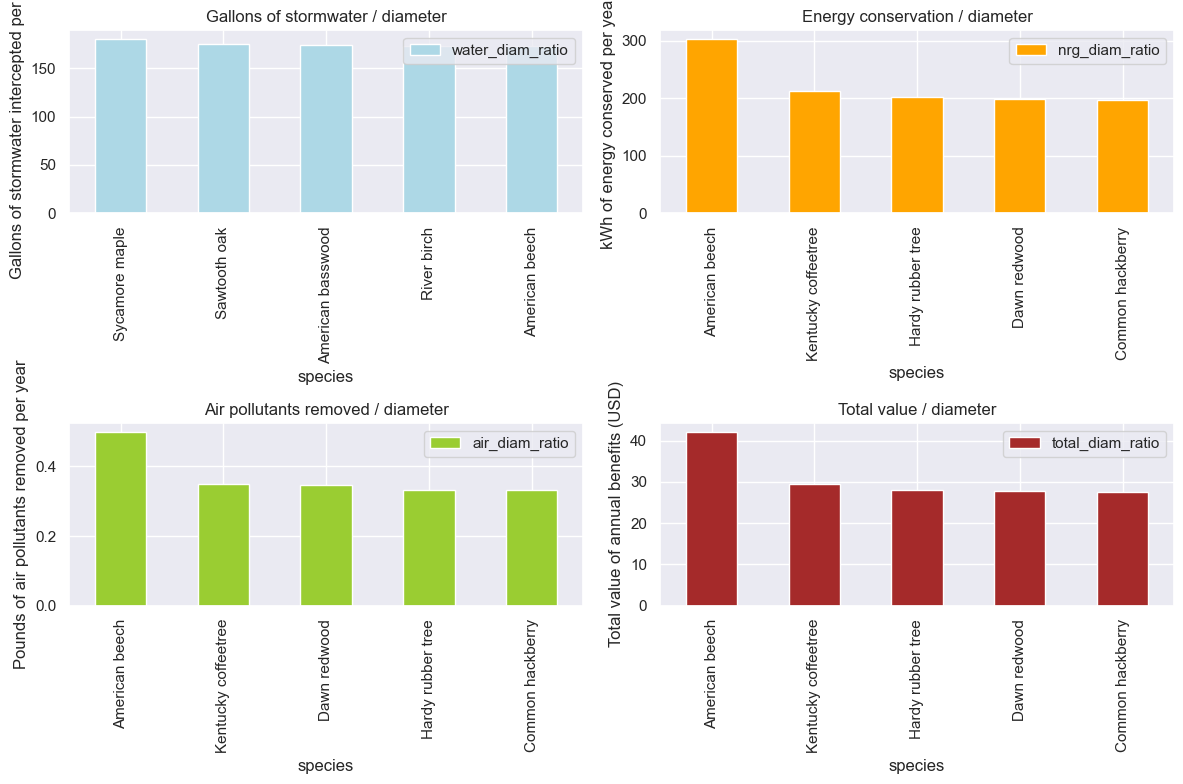

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

w_sp_top_5.plot(
    kind="bar",  
    y="water_diam_ratio", 
    ax=axes[0,0], 
    title="Gallons of stormwater / diameter", 
    color="lightblue", 
    ylabel="Gallons of stormwater intercepted per year")

e_sp_top_5.plot(
    kind="bar", 
    y="nrg_diam_ratio", 
    ax=axes[0,1], 
    title="Energy conservation / diameter", 
    color="orange", 
    ylabel="kWh of energy conserved per year")

a_sp_top_5.plot(
    kind="bar", 
    y="air_diam_ratio", 
    ax=axes[1,0], 
    title="Air pollutants removed / diameter", 
    color="yellowgreen", 
    ylabel="Pounds of air pollutants removed per year")

t_sp_top_5.plot(
    kind="bar", 
    y="total_diam_ratio", 
    ax=axes[1,1], 
    title="Total value / diameter", 
    color="brown", 
    ylabel="Total value of annual benefits (USD)")

plt.tight_layout()
plt.show()


species: resource(1-5):
- American beech: w5 e1 a1 t1
- Common hackberry: _ e5 a5 t5
- Dawn redwood: _ e4 a3 t4
- Hardy rubber tree: _ e3 a4 t3
- Kentucky coffeetree: _ e2 a2 t2
- River birch: w4 _ _ _
- Sawtooth oak: w2 _ _ _
- Sycamore maple: w1 _ _ _

American beech wins overall for highest average environmental metrics, species-wise, but places 5th against Sycamore maple for stormwater intercepted per year.  

Looking at the composition of the top 5 for each metric, we see recurring species in each category except stormwater intercepted. Since the species that place well in stormwater interception don't appear in the other metrics, including total amount contributed, we can assume that these species (river birch, sawtooth oak, sycamore maple) are great at stormwater interception but lack the same ability in energy conservation or air pollutant collection. The recurring species, on the other hand, are more well-balanced across all metrics.

Just in case, let's check for outliers in the species that we've included in the graph above, specifically for the stormwater ratio.

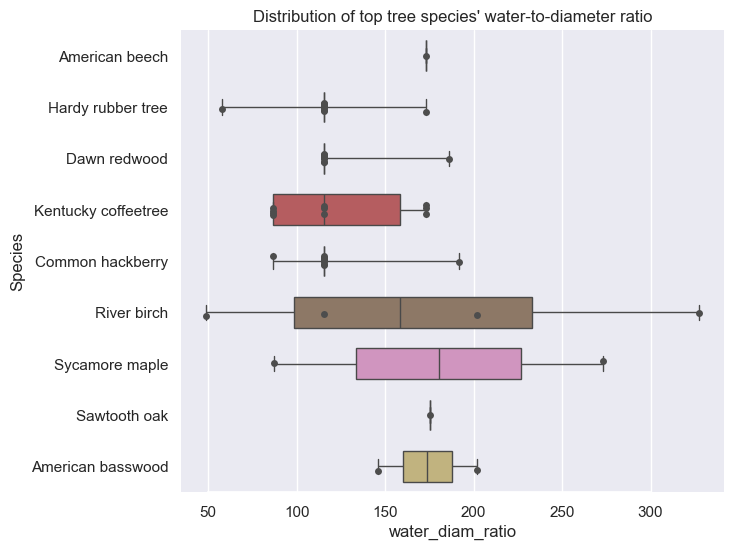

In [73]:
# checking for outliers in these species
spec_water_df = pd.DataFrame({"species":[], "water_diam_ratio":[]})

for species in ["American beech", "Hardy rubber tree", "Dawn redwood", "Kentucky coffeetree", "Common hackberry", "River birch", "Sycamore maple", "Sawtooth oak", "American basswood"]:
    spec_water_df = pd.concat([spec_water_df, tree_df[tree_df["species"] == species][['species', 'water_diam_ratio']]])


sns.set_theme(style="darkgrid")
#sp_color = {"River birch": "turquoise", "Japanese zelkova": "gold", "Red maple": "crimson", "Kentucky coffeetree": "cornflowerblue"}
f, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(
spec_water_df, x="water_diam_ratio", y="species", hue="species",
whis=[0, 100], width=.6
)

sns.stripplot(spec_water_df, x="water_diam_ratio", y="species", size=5, color=".3")

ax.xaxis.grid(True)
ax.set(ylabel="Species", title="Distribution of top tree species' water-to-diameter ratio")
sns.despine(trim=True, left=True)
plt.show()

Looks like there are no obvious outliers, though many species only have very few observations. The dataset from which these trees were drawn is very small, so it's unlikely that these statistics are representative of the wider tree population in NYC. However, since these original metrics were calculated by taking species and diameter into account, these calculated metrics likely apply for trees with the same diameter and species. (???????????????????????????????? cite site)

#### Predicting the species of unknown trees

In [ ]:
tree_df[tree_df["species"]=="Unknown"]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,species,diameter,water_saved,energy_saved,air_saved,total_saved,water_diam_ratio,nrg_diam_ratio,air_diam_ratio,total_diam_ratio
74,-73.911556,40.764391,Queens,11103,42-16,28 AVENUE,0,3571053,401,2024-06-30,...,Unknown,10.0,2177.0,1432.0,3.0,229.98,217.7,143.20,0.3,22.9980
152,-74.073008,40.628408,Staten Island,10304,98,NAVY PIER CT,0,9586995,501,2024-06-30,...,Unknown,4.0,32.0,23.0,0.0,3.39,8.0,5.75,0.0,0.8475


Let's try to first identify the first tree (10-inch diameter, on 28th Ave in Queens).

In [76]:
tree_df[tree_df["diameter"] == 10.0]

,lng,lat,Borough,ZipCode,BuildingNumber,StreetName,FiscalYear,PlantingSpaceID,CommunityBoard,PlantingSeason,...,species,diameter,water_saved,energy_saved,air_saved,total_saved,water_diam_ratio,nrg_diam_ratio,air_diam_ratio,total_diam_ratio
74,-73.911556,40.764391,Queens,11103,42-16,28 AVENUE,0,3571053,401,2024-06-30,...,Unknown,10.0,2177.0,1432.0,3.0,229.98,217.7,143.2,0.3,22.998
115,-73.869795,40.735939,Queens,11373,56-25,92 STREET,0,3638929,404,2024-06-30,...,Sugar maple,10.0,1310.0,1067.0,2.0,164.69,131.0,106.7,0.2,16.469
179,-73.830944,40.826256,Bronx,10465,2600,LAFAYETTE AVENUE,0,2466656,210,2024-12-31,...,London planetree,10.0,1696.0,1268.0,2.0,191.07,169.6,126.8,0.2,19.107
195,-73.843765,40.723123,Queens,11375,108-14,70 AV,0,5001360,406,2024-12-31,...,Japanese flowering cherry,10.0,423.0,473.0,1.0,69.77,42.3,47.3,0.1,6.977
197,-73.856207,40.744466,Queens,11368,49-29,108 ST,0,3947424,404,2024-12-31,...,American elm,10.0,877.0,641.0,1.0,96.65,87.7,64.1,0.1,9.665


In [79]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [80]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [100]:
import plotly.io as pio
pio.renderers.default = "notebook"

In [103]:
tree_df[tree_df["species"]=="Unknown"]["TreeID"]

74      3272151
152    12812658
Name: TreeID, dtype: int64

In [206]:
# interactive plot
import plotly.express as px
import plotly.graph_objects as go

fig = px.scatter_3d(tree_df, x='water_diam_ratio', y='nrg_diam_ratio', z='air_diam_ratio', color='TreeID',
                    title="4D Interactive Scatter Plot")
highlight_df = tree_df.loc[[74, 152]]

# highlight unknown species trees
fig.add_trace(
    go.Scatter3d(
        x=highlight_df["water_diam_ratio"],
        y=highlight_df["nrg_diam_ratio"],
        z=highlight_df["air_diam_ratio"],
        mode="markers",
        marker=dict(
            size=8,
            color="yellowgreen",
            symbol="circle"
        ),
        name="unknown"
    )
)
fig.update_layout(
    scene_camera=dict(
        eye=dict(x=1, y=1, z=0.3),  
      
    )
)
fig.show()


ughhhh better to kNN this because who said visual inspection was enough here (I think it is enough here)


Closest three points to 8 5.75 0: 1447532, 2268891, 2241336
Closest three points to 217.7, 143.2, 0.3: 2270572, 2251648, 3357269

In [316]:
tree_df[(tree_df["TreeID"]== 1447532) | (tree_df["TreeID"]== 2268891) | (tree_df["TreeID"]== 2241336)]["species"]

177         Katsura tree
213                Apple
284    Littleleaf linden
Name: species, dtype: object

In [317]:
tree_df[(tree_df["TreeID"]== 2270572) | (tree_df["TreeID"]== 2251648) | (tree_df["TreeID"]== 3357269)]["species"]

72     Thornless honeylocust
191    Thornless honeylocust
228         Japanese zelkova
Name: species, dtype: object

A kind of vague "kNN" through visual inspection gets us no consensus for the first tree, but 2 out of 3 neighbors for the second tree are thornless honeylocusts. Let's increase our neighbor hyperparameter to 5 and see how our results change.

Let's normalize our features and perform a proper kNN, first with k=3 as a starting k-value.

In [213]:
%pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 4.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 3.8 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [224]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
# normalize
from sklearn.preprocessing import StandardScaler
scaled_eco_df = pd.DataFrame(StandardScaler().fit_transform(tree_df[['water_diam_ratio', 'nrg_diam_ratio', 'air_diam_ratio']]), columns=['water_diam_ratio', 'nrg_diam_ratio', 'air_diam_ratio'])



Features were normalized in order to perform kNN on them. Otherwise, the three units (gallons-per-year, kWh-per-year, and pounds-per-year) would interfere with proper measurement of distance between points, and affect the kNN results.

In [297]:
scaled_eco_df["TreeID"] = tree_df["TreeID"]

In [ ]:
# normalized rows turned out to overlap (esp Tree #1)
import numpy as np

jitter = 0.1

scaled_eco_df["x_jitter"] = scaled_eco_df["water_diam_ratio"] + np.random.normal(0, jitter, len(scaled_eco_df))
scaled_eco_df["y_jitter"] = scaled_eco_df["nrg_diam_ratio"] + np.random.normal(0, jitter, len(scaled_eco_df))
scaled_eco_df["z_jitter"] = scaled_eco_df["air_diam_ratio"] + np.random.normal(0, jitter, len(scaled_eco_df))

In [318]:
# kNN k=3
coords = scaled_eco_df[['water_diam_ratio', 'nrg_diam_ratio', 'air_diam_ratio']].values
k = 3

scaled_eco_df["group"] = "other"

nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords) # incl self
distances, indices = nbrs.kneighbors(coords)

# unknown trees
target_1 = scaled_eco_df.query("TreeID == 3272151").index[0]
target_2 = scaled_eco_df.query("TreeID == 12812658").index[0]

# neighbors
neighbors_1 = indices[target_1][1:]
neighbors_2 = indices[target_2][1:]
neighbors_1_idx = scaled_eco_df.iloc[neighbors_1].index
neighbors_2_idx = scaled_eco_df.iloc[neighbors_2].index

scaled_eco_df.loc[neighbors_1_idx, "group"] = "neighbors_1"
scaled_eco_df.loc[neighbors_2_idx, "group"] = "neighbors_2"
scaled_eco_df.loc[target_1, "group"] = "target_1"
scaled_eco_df.loc[target_2, "group"] = "target_2"

color_map = {
    "other": "lightgray",
    "neighbors_1": "green",
    "neighbors_2": "green",
    "target_1": "orange",
    "target_2": "orange",
    "both": "purple"
}

size_map = {
    "other": 3,
    "neighbors_1": 2,
    "neighbors_2": 6,
    "target_1": 2,
    "target_2": 6,
    "both": 8
}

fig = px.scatter_3d(
    scaled_eco_df, x='water_diam_ratio', y='nrg_diam_ratio', z='air_diam_ratio',
    color="group",
    color_discrete_map=color_map,
    size=[1 for x in scaled_eco_df["group"].map(size_map)],
    hover_data=["TreeID"]
)
# add jitter
fig = px.scatter_3d(
    scaled_eco_df,
    x="x_jitter", y="y_jitter", z="z_jitter", opacity=0.5,
    color="group",
    color_discrete_map=color_map,
)

fig.show()

In [319]:
# first point neighbors
neighbors_1 = scaled_eco_df[scaled_eco_df["group"] == "neighbors_1"]

In [320]:
tree_df[tree_df['TreeID'].isin(neighbors_1["TreeID"])]["species"]

19    Bur oak
20    Bur oak
21    Bur oak
Name: species, dtype: object

The results of the k=3 kNN with properly normalized features say that Unknown Tree #1 is a bur oak. Let's look at Unknown Tree #2's neighbors.

In [321]:
neighbors_2 = scaled_eco_df[scaled_eco_df["group"] == "neighbors_2"]

In [322]:
tree_df[tree_df['TreeID'].isin(neighbors_2["TreeID"])]["species"]

163                 Norway maple
251    Japanese flowering cherry
277        Thornless honeylocust
Name: species, dtype: object

No conclusive species for Unknown Tree #2, so let's try another value of k, k=5.

In [323]:
# kNN
coords = scaled_eco_df[['water_diam_ratio', 'nrg_diam_ratio', 'air_diam_ratio']].values
k = 5

scaled_eco_df["group"] = "other"

nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords) # incl self
distances, indices = nbrs.kneighbors(coords)

# unknown trees
target_1 = scaled_eco_df.query("TreeID == 3272151").index[0]
target_2 = scaled_eco_df.query("TreeID == 12812658").index[0]

# neighbors
neighbors_1 = indices[target_1][1:]
neighbors_2 = indices[target_2][1:]
neighbors_1_idx = scaled_eco_df.iloc[neighbors_1].index
neighbors_2_idx = scaled_eco_df.iloc[neighbors_2].index

scaled_eco_df.loc[neighbors_1_idx, "group"] = "neighbors_1"
scaled_eco_df.loc[neighbors_2_idx, "group"] = "neighbors_2"
scaled_eco_df.loc[target_1, "group"] = "target_1"
scaled_eco_df.loc[target_2, "group"] = "target_2"

color_map = {
    "other": "lightgray",
    "neighbors_1": "green",
    "neighbors_2": "green",
    "target_1": "orange",
    "target_2": "orange",
    "both": "purple"
}

size_map = {
    "other": 3,
    "neighbors_1": 2,
    "neighbors_2": 6,
    "target_1": 2,
    "target_2": 6,
    "both": 8
}

fig = px.scatter_3d(
    scaled_eco_df, x='water_diam_ratio', y='nrg_diam_ratio', z='air_diam_ratio',
    color="group",
    color_discrete_map=color_map,
    size=[1 for x in scaled_eco_df["group"].map(size_map)],
    hover_data=["TreeID"]
)
# add jitter
fig = px.scatter_3d(
    scaled_eco_df,
    x="x_jitter", y="y_jitter", z="z_jitter", opacity=0.5,
    color="group",
    color_discrete_map=color_map,
)

fig.show()

After we've done our k=5 kNN visualization, let's examine the neighbors in detail.

In [331]:
# first point neighbors
neighbors_1 = scaled_eco_df[scaled_eco_df["group"] == "neighbors_1"]
tree_df[tree_df['TreeID'].isin(neighbors_1["TreeID"])]["species"]

9     Shingle oak
11    Shingle oak
19        Bur oak
20        Bur oak
21        Bur oak
Name: species, dtype: object

The results of the k=5 kNN with properly normalized features agree with the earlier k=3 result, that Unknown Tree #1 is a bur oak. Let's look at Unknown Tree #2's neighbors.

In [330]:
neighbors_2 = scaled_eco_df[scaled_eco_df["group"] == "neighbors_2"]
tree_df[tree_df['TreeID'].isin(neighbors_2["TreeID"])]["species"]

154                 Callery pear
163                 Norway maple
230                 Callery pear
251    Japanese flowering cherry
277        Thornless honeylocust
Name: species, dtype: object

It looks like there's no clear majority for Unknown Tree #2, even at a higher k value. However, the species that occurs most in its neighbors is the Callery pear. It's not a majority, so we can't assign Unknown Tree #2 to a species. 

From  estimated ecological metrics alone, we can't seem to pinpoint species for specific trees. This means trees of different species have lots of overlap in their ability to contribute to our environment. 

#### Dimensionality reduction with PCA

Can we see a natural clustering of points into species if we reduce the number of dimensions?

In [367]:
X_scaled = scaled_eco_df[['water_diam_ratio', 'nrg_diam_ratio', 'air_diam_ratio']].values

In [379]:
from sklearn.decomposition import PCA

In [380]:
pca = PCA().fit(X_scaled)
pca.explained_variance_ratio_

array([0.76238805, 0.18643813, 0.05117382])

Two components seem to explain most of the data, so let's retain two components for the PCA.

In [381]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# silhouette scores
range_n_clusters = [2, 3, 4, 5, 6]

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # compute silhouette scores
    sample_silhouette_values = silhouette_samples(X_pca, cluster_labels)


For n_clusters = 2 The average silhouette_score is : 0.5866937758030553
For n_clusters = 3 The average silhouette_score is : 0.4961998735684476
For n_clusters = 4 The average silhouette_score is : 0.5244694682615051
For n_clusters = 5 The average silhouette_score is : 0.5744888414468778
For n_clusters = 6 The average silhouette_score is : 0.5881450066824756


The highest silhouette values were for K=2 and K=6, so let's try those out.

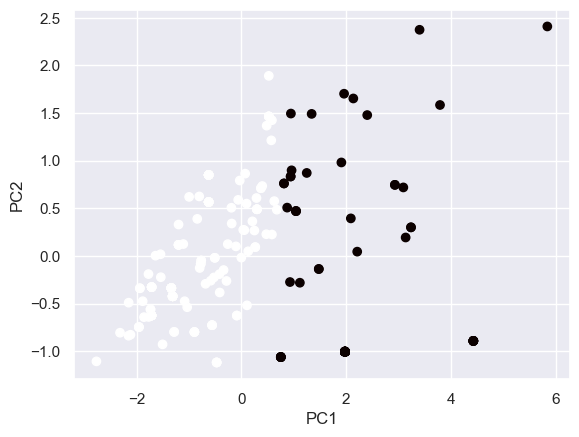

In [ ]:
# K = 2 and K = 6

# K = 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

plt.show()

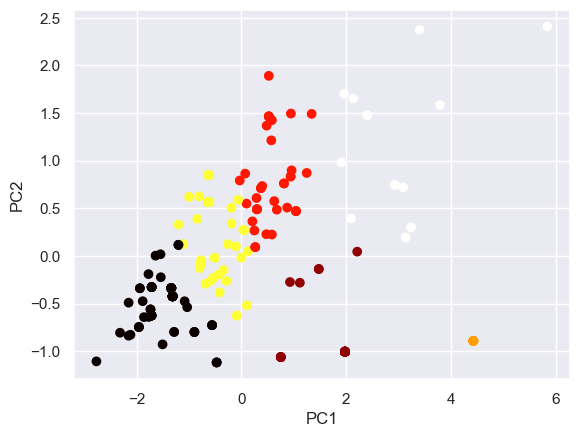

In [385]:
# K = 6
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

plt.show()

Looks like there's no natural structure within these ecological features that allows us to differentiate species based on ecological data alone, even when $K$ varies. The lack of tight, spherical clusters tells us standard KMeans isn't ideal for this data.

In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns=["water_diam_ratio", "nrg_diam_ratio", "air_diam_ratio"],
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print(loadings)

     water_diam_ratio  nrg_diam_ratio  air_diam_ratio
PC1          0.505045        0.611123        0.609473
PC2          0.863039       -0.349696       -0.364522


Examining the PCA loadings tells us that all three ecological metrics contribute about equal importance to the first component, while the stormwater feature contributes much more to the second component than the energy or air pollutant features. For PC1, all three features increase together, which may represent how these tend to increase with diameter of a tree. For PC2, the stormwater feature moves positively, while energy and air move negatively (to a lesser degree). This might indicate how PC2 represents trees that are great at conserving stormwater, but do not have similarly high measures in energy and air conservation.

Even if a relationship can't be seen naturally through clustering, we could use a classifier to predict the class of these unknown-species trees. However, as seen below, we have class imbalance (some species only have one or two trees in the dataset) and a very small dataset, so it's unlikely that a classifier could produce accurate results for the wider population of NYC trees.

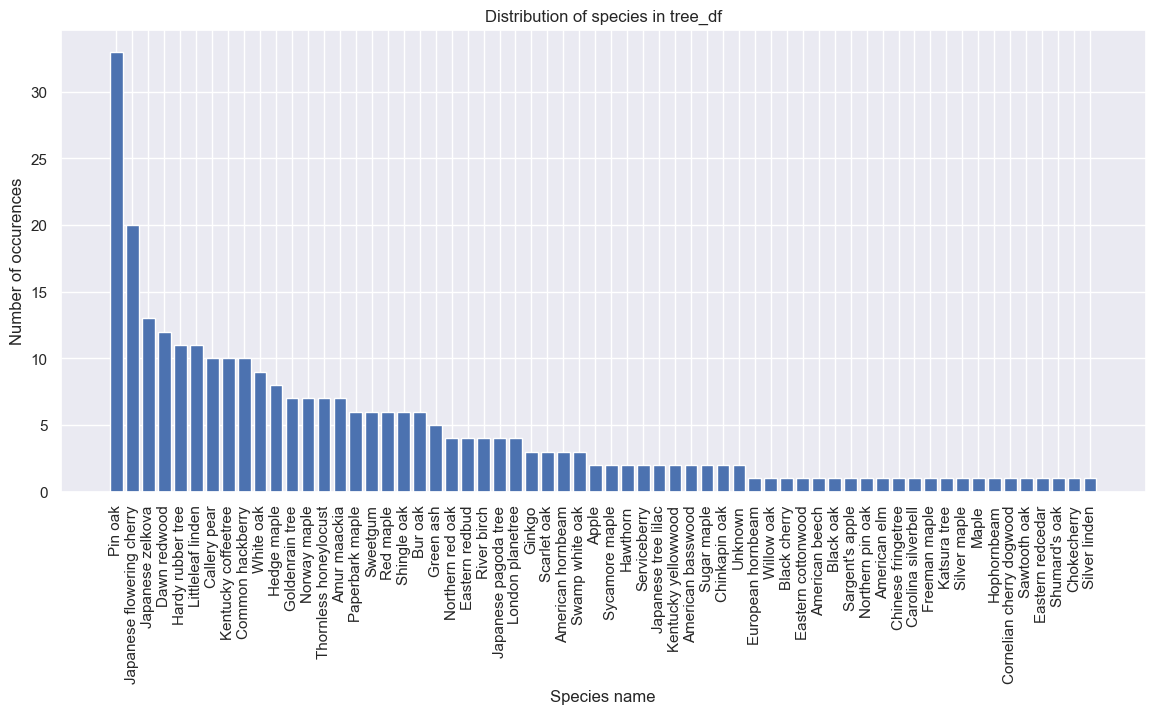

In [456]:
plt.figure(figsize=(14,6))
plt.bar(tree_df["species"].value_counts().keys(), tree_df["species"].value_counts().values)
plt.title("Distribution of species in tree_df")
plt.xlabel("Species name")
plt.ylabel("Number of occurences")
plt.xticks(tree_df["species"].value_counts().keys(), rotation=90)
plt.show()

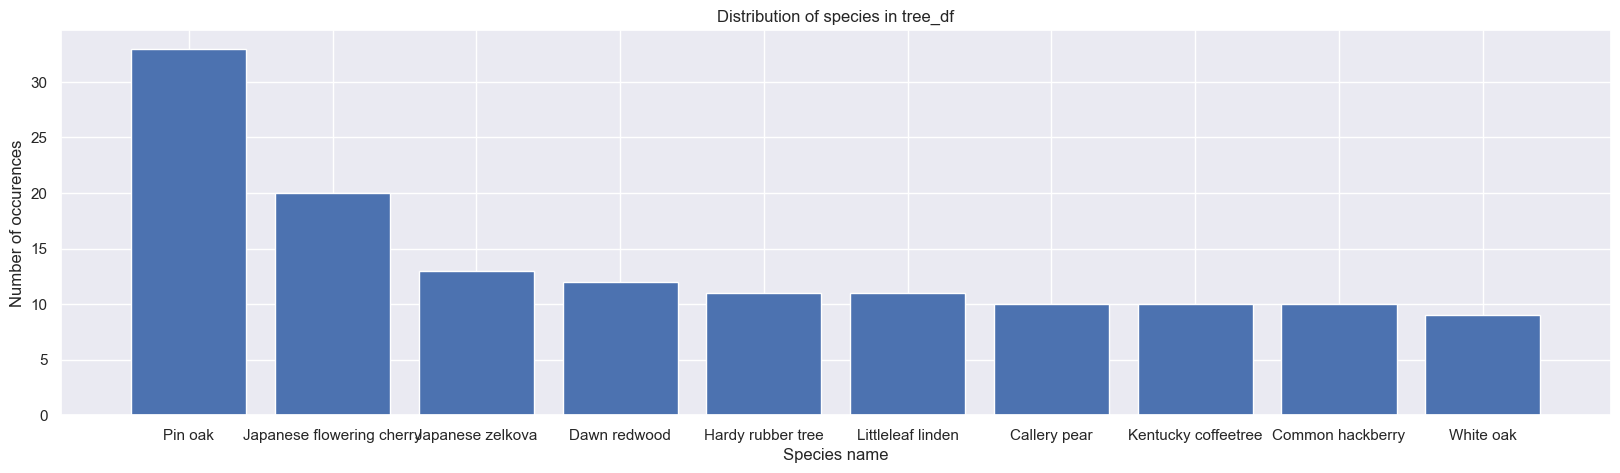

In [ ]:
# just top 10
plt.figure(figsize=(20,5))
plt.bar(tree_df["species"].value_counts().keys()[:10], tree_df["species"].value_counts().values[:10])
plt.title("Distribution of species in tree_df")
plt.xlabel("Species name")
plt.ylabel("Number of occurences")
plt.show()

## Takeaways
- NYC Parks plants many pin oaks (as of recently), despite the fact that pin oaks' ecological metrics do not stand out for their environmental effects.
- It's difficult to differentiate species just from environmental data: species overlap in their ecological metrics, no single species stands out for being better than all others!
- Thus, even when focusing on ecological benefits, it's likely that no single tree species should be planted more than others.
    - Though this datset is small, the ecological benefits calculated for each tree is from a calculator (USDA's i-Tree software, as explained on this page: https://tree-map.nycgovparks.org/tree-map/learn/benefits) and even if sunlight or distance from a building is varied, the ecological metrics are very similar. The metrics for these trees shouldn't differ a lot from the wider population, but this would require more data to support.
- Exploring and analyzing this dataset made me realize that trees, though mostly only thought of as shade-providing or nice to look at, are important for the environment that exists under the concrete sidewalks and asphalt roads of New York City, and for those who live in it. 

- Further exploration could focus on frequency of tree planting, any zip codes or streets where specific species of trees are planted, biodiversity metrics, and more.